In [184]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
# import lib_plot

from lib_fitting import lin_fit
from lib_equations import trapezoidal, Simpson, loc_trapezoidal, loc_Simpson


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **Test for the functions: $\int_{-1} ^1 e^x \approx 2.350402$**

In [185]:
# Params
a = -1
b = 1
dx_ = 1e-6

func = np.exp

res_t = trapezoidal(func, a, b, dx_)

# Results
print(f'a = {a}')
print(f'b = {b}\n')

print('I{a, b} =', res_t)

a = -1
b = 1

I{a, b} = 2.3504023872877986


In [186]:
res_s = Simpson(func, a, b, dx_)

print(f'a = {a}')
print(f'b = {b}\n')

print('I{a, b} =', res_s)

a = -1
b = 1

I{a, b} = 2.3504023872876023


In [187]:
diff = abs(res_t - res_s)
print('diff = ', diff)

diff =  1.9628743075372768e-13


# **Test for the scaling in $\int_{x_0} ^{x_0 + \delta x} \sin^2 \frac{x}{2} dx $**

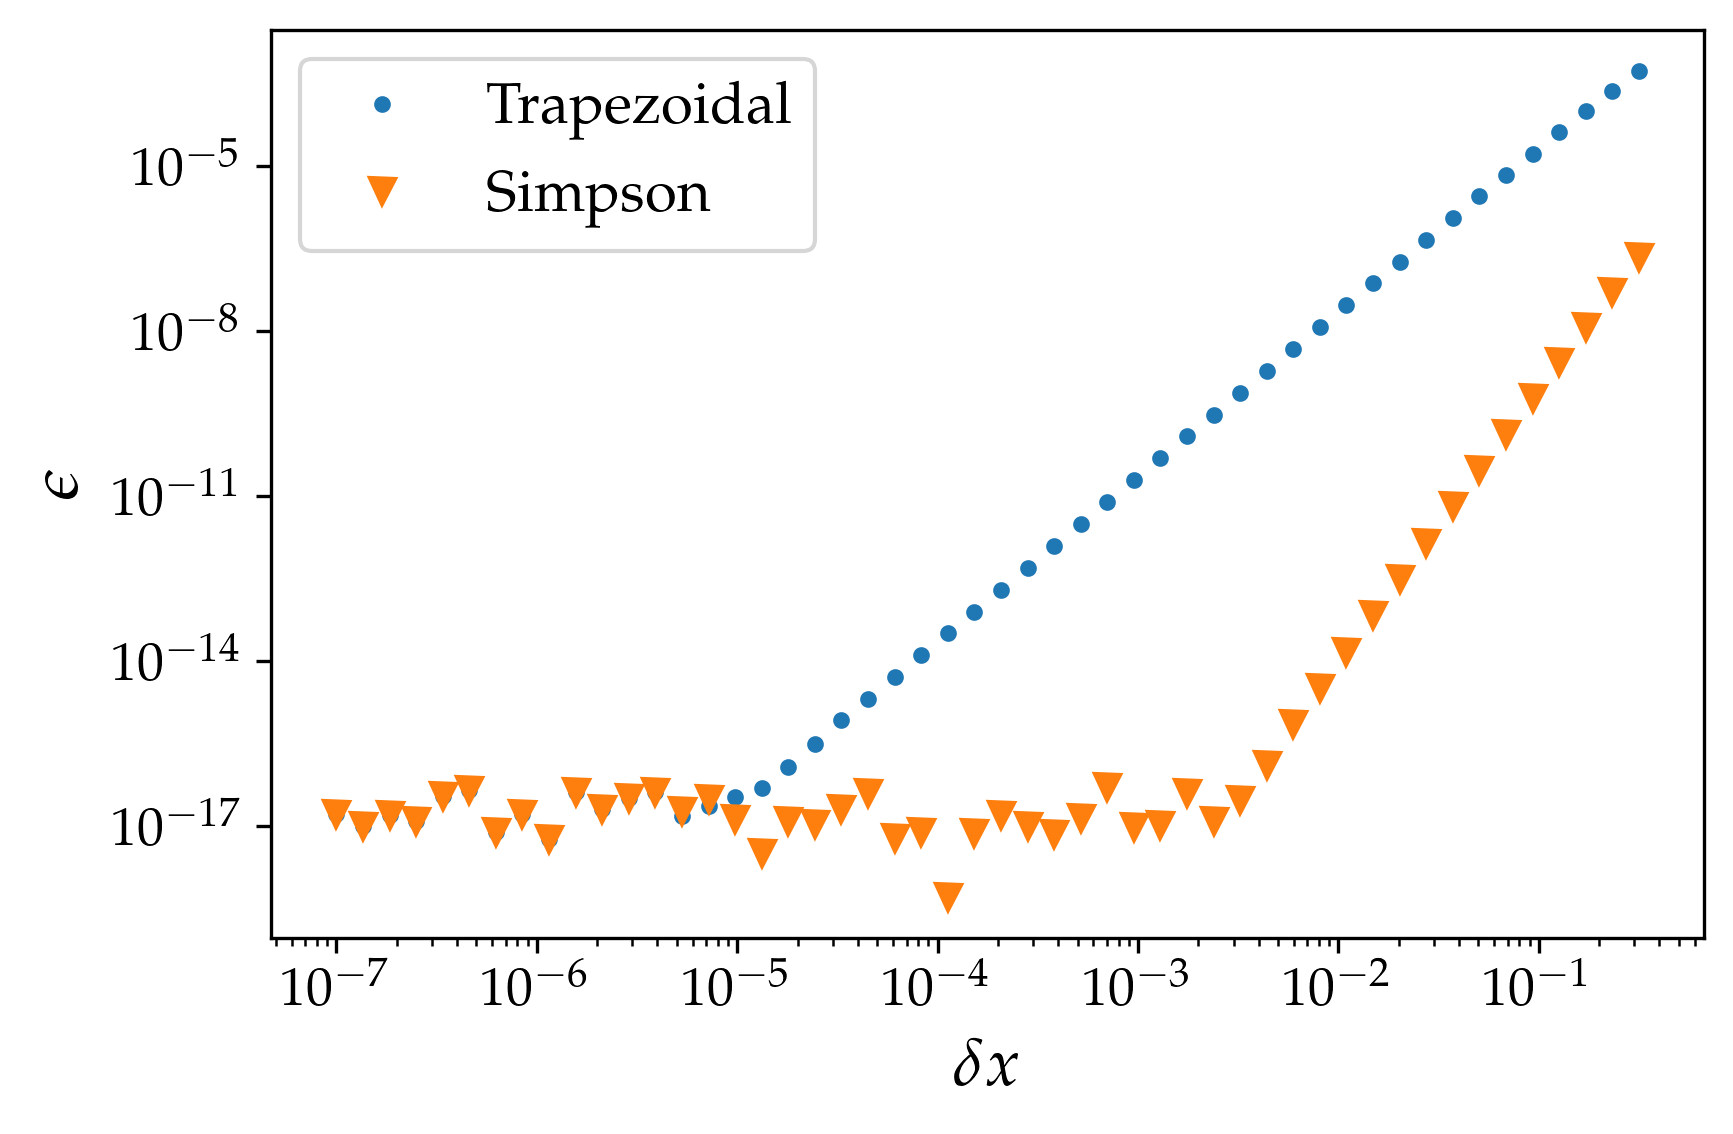

In [188]:
func = lambda x: np.sin(x/2)**2
sols = lambda x: (x - np.sin(x))/2
x_0 = 1.

dx_arr = np.logspace(-7, -0.5, 50)
error = [[], []]
for dx_ in dx_arr:
    for i in range(2):
        gr_spec = [['Trapezoidal', '.', loc_trapezoidal], 
                ['Simpson', 'v', loc_Simpson ]]
        
        true = sols(x_0+dx_) - sols(x_0)
        f_int = gr_spec[i][2]
        
        err = np.abs(f_int(func, x_0, dx=dx_) - true)
        error[i].append(err)

plt.figure(figsize=(6, 4))
for i in range(2):
    plt.loglog(dx_arr, error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$\delta x$')
plt.ylabel(r'$\epsilon$')
plt.legend()
plt.tight_layout()

plt.savefig('plots/confr_locals')
plt.show()


## **Check slope of *Trapezoid***

dof = 28

a = 2.98e+00 +/- 1.590e-01
b = -1.71e+00 +/- 4.264e-01

Chi2 = 0.01
p-val = 1.00


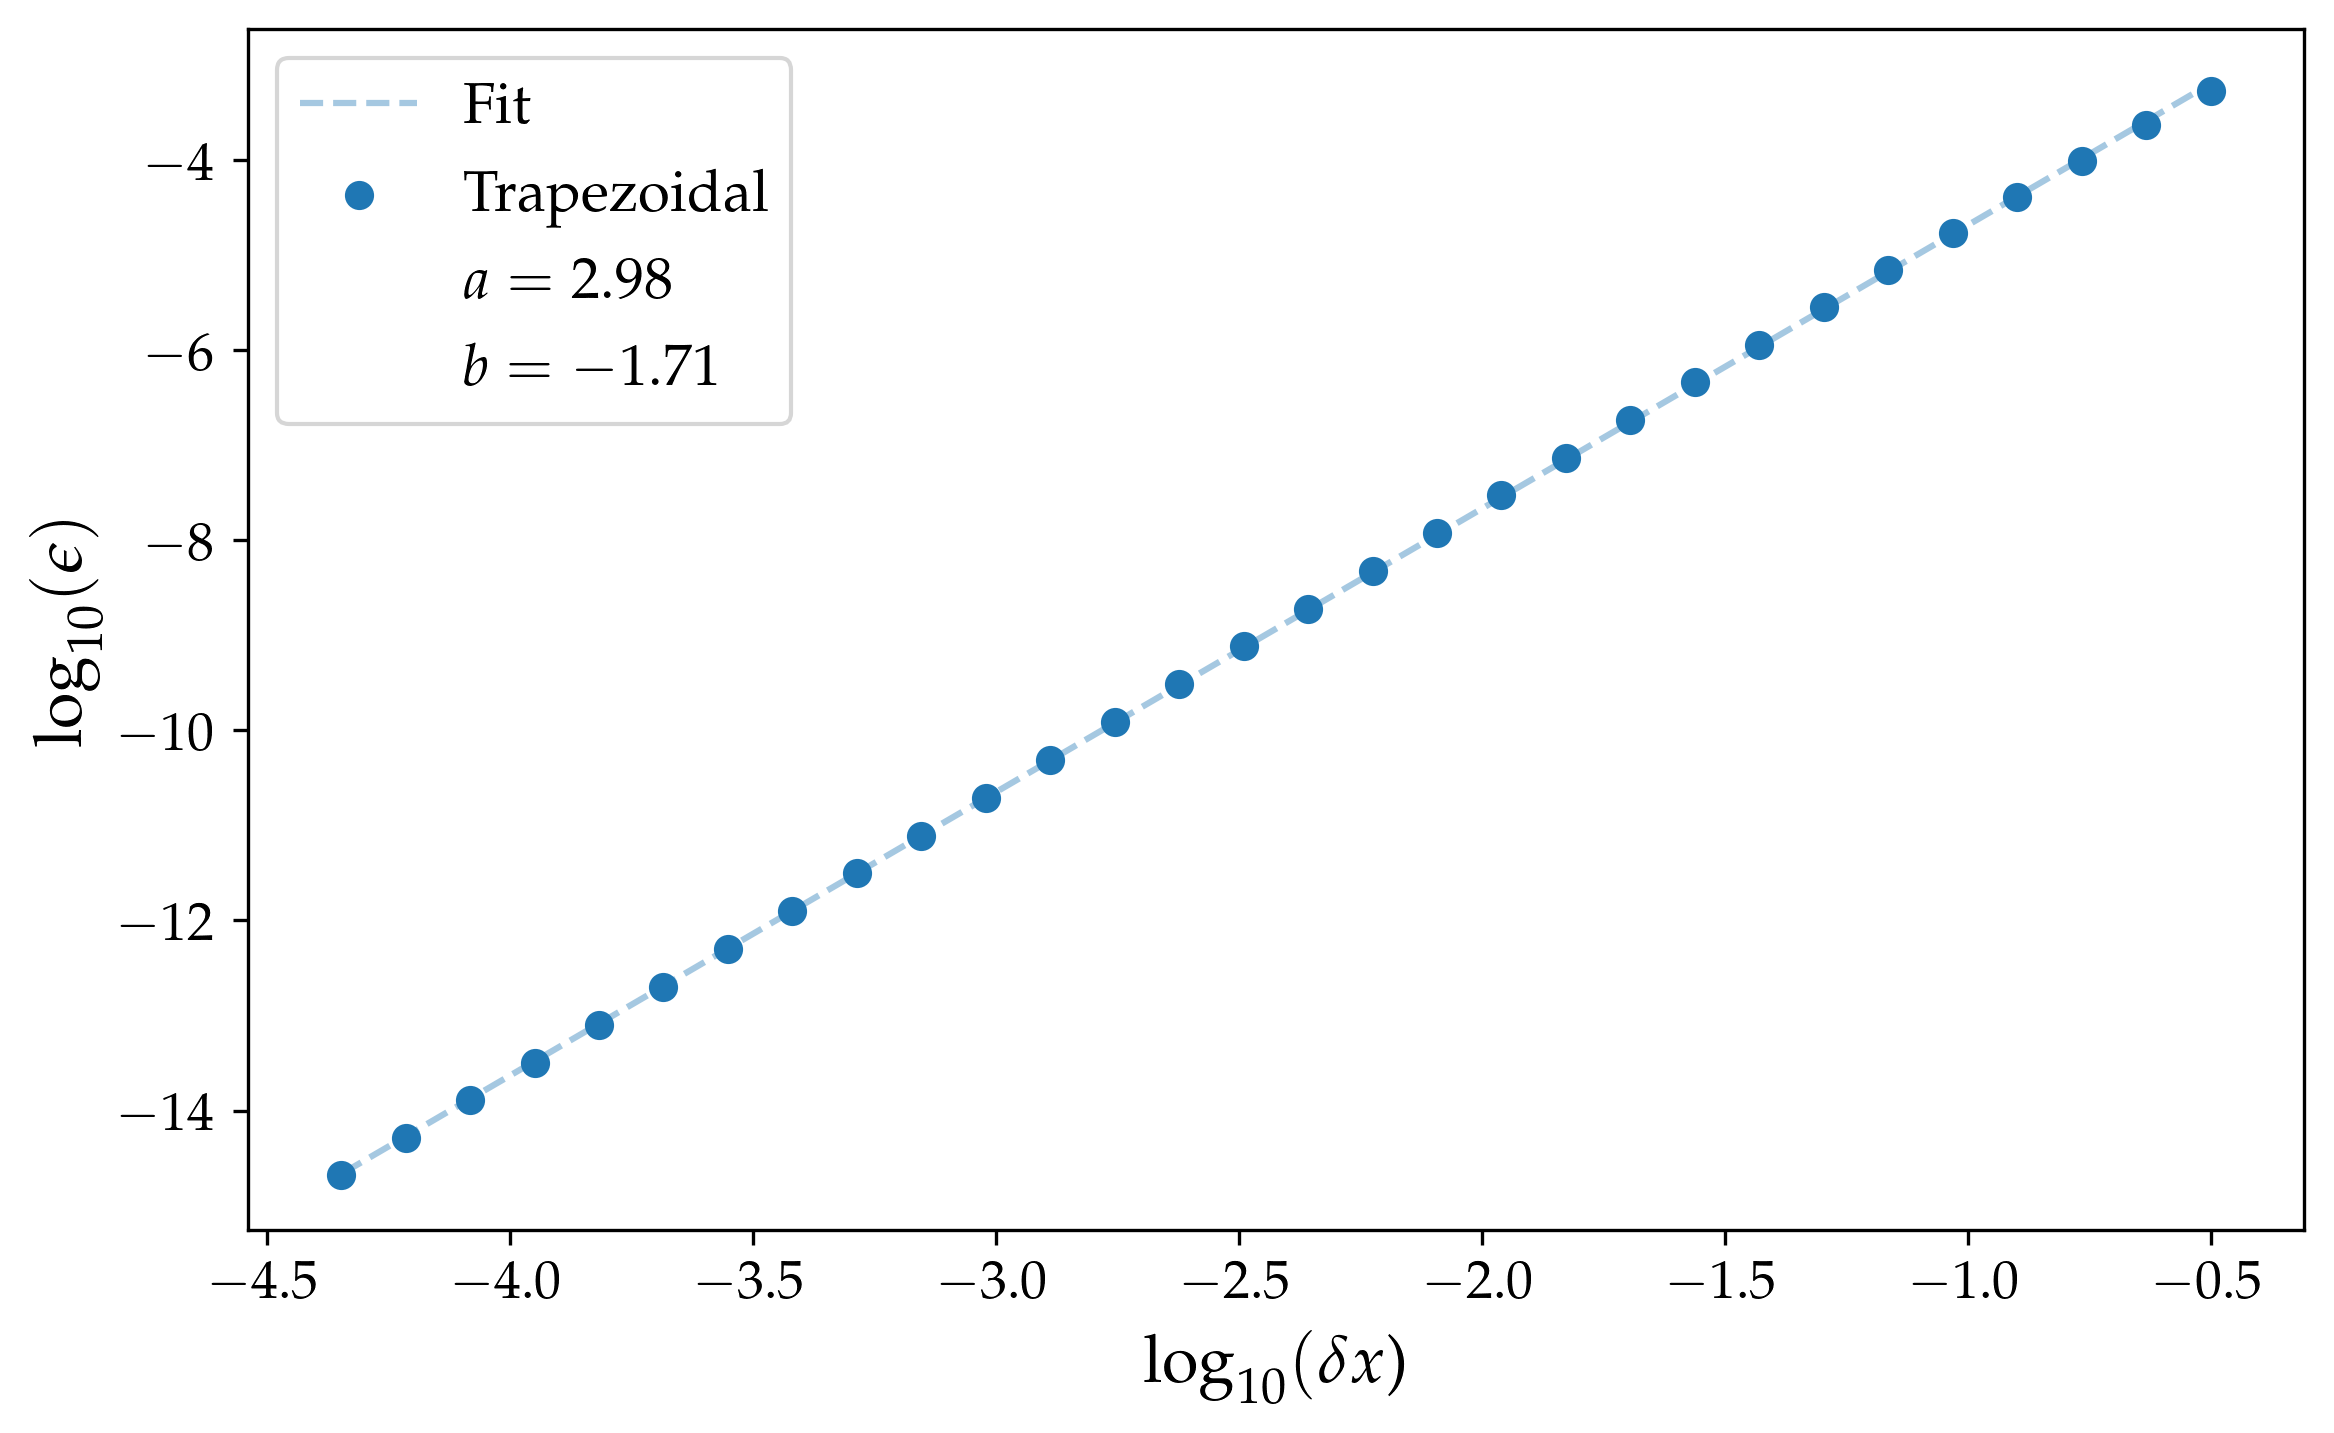

([np.float64(2.981410021822419), np.float64(-1.7075174067648329)],
 array([[0.02528516, 0.06127782],
        [0.06127782, 0.18183825]]),
 np.float64(0.013693643678503509),
 np.float64(1.0))

In [189]:
i = 0 
cut = 20
dx, eps_dx = (dx_arr[cut:], error[i][cut:])

lin_fit(np.log10(dx), np.log10(eps_dx),
        mar='o', col='C0', name_points='Trapezoidal',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/Fit_LocTrap')

## **Check slope of *Simpson***

dof = 13

a = 4.96e+00 +/- 4.505e-01
b = -4.12e+00 +/- 6.934e-01

Chi2 = 0.01
p-val = 1.00


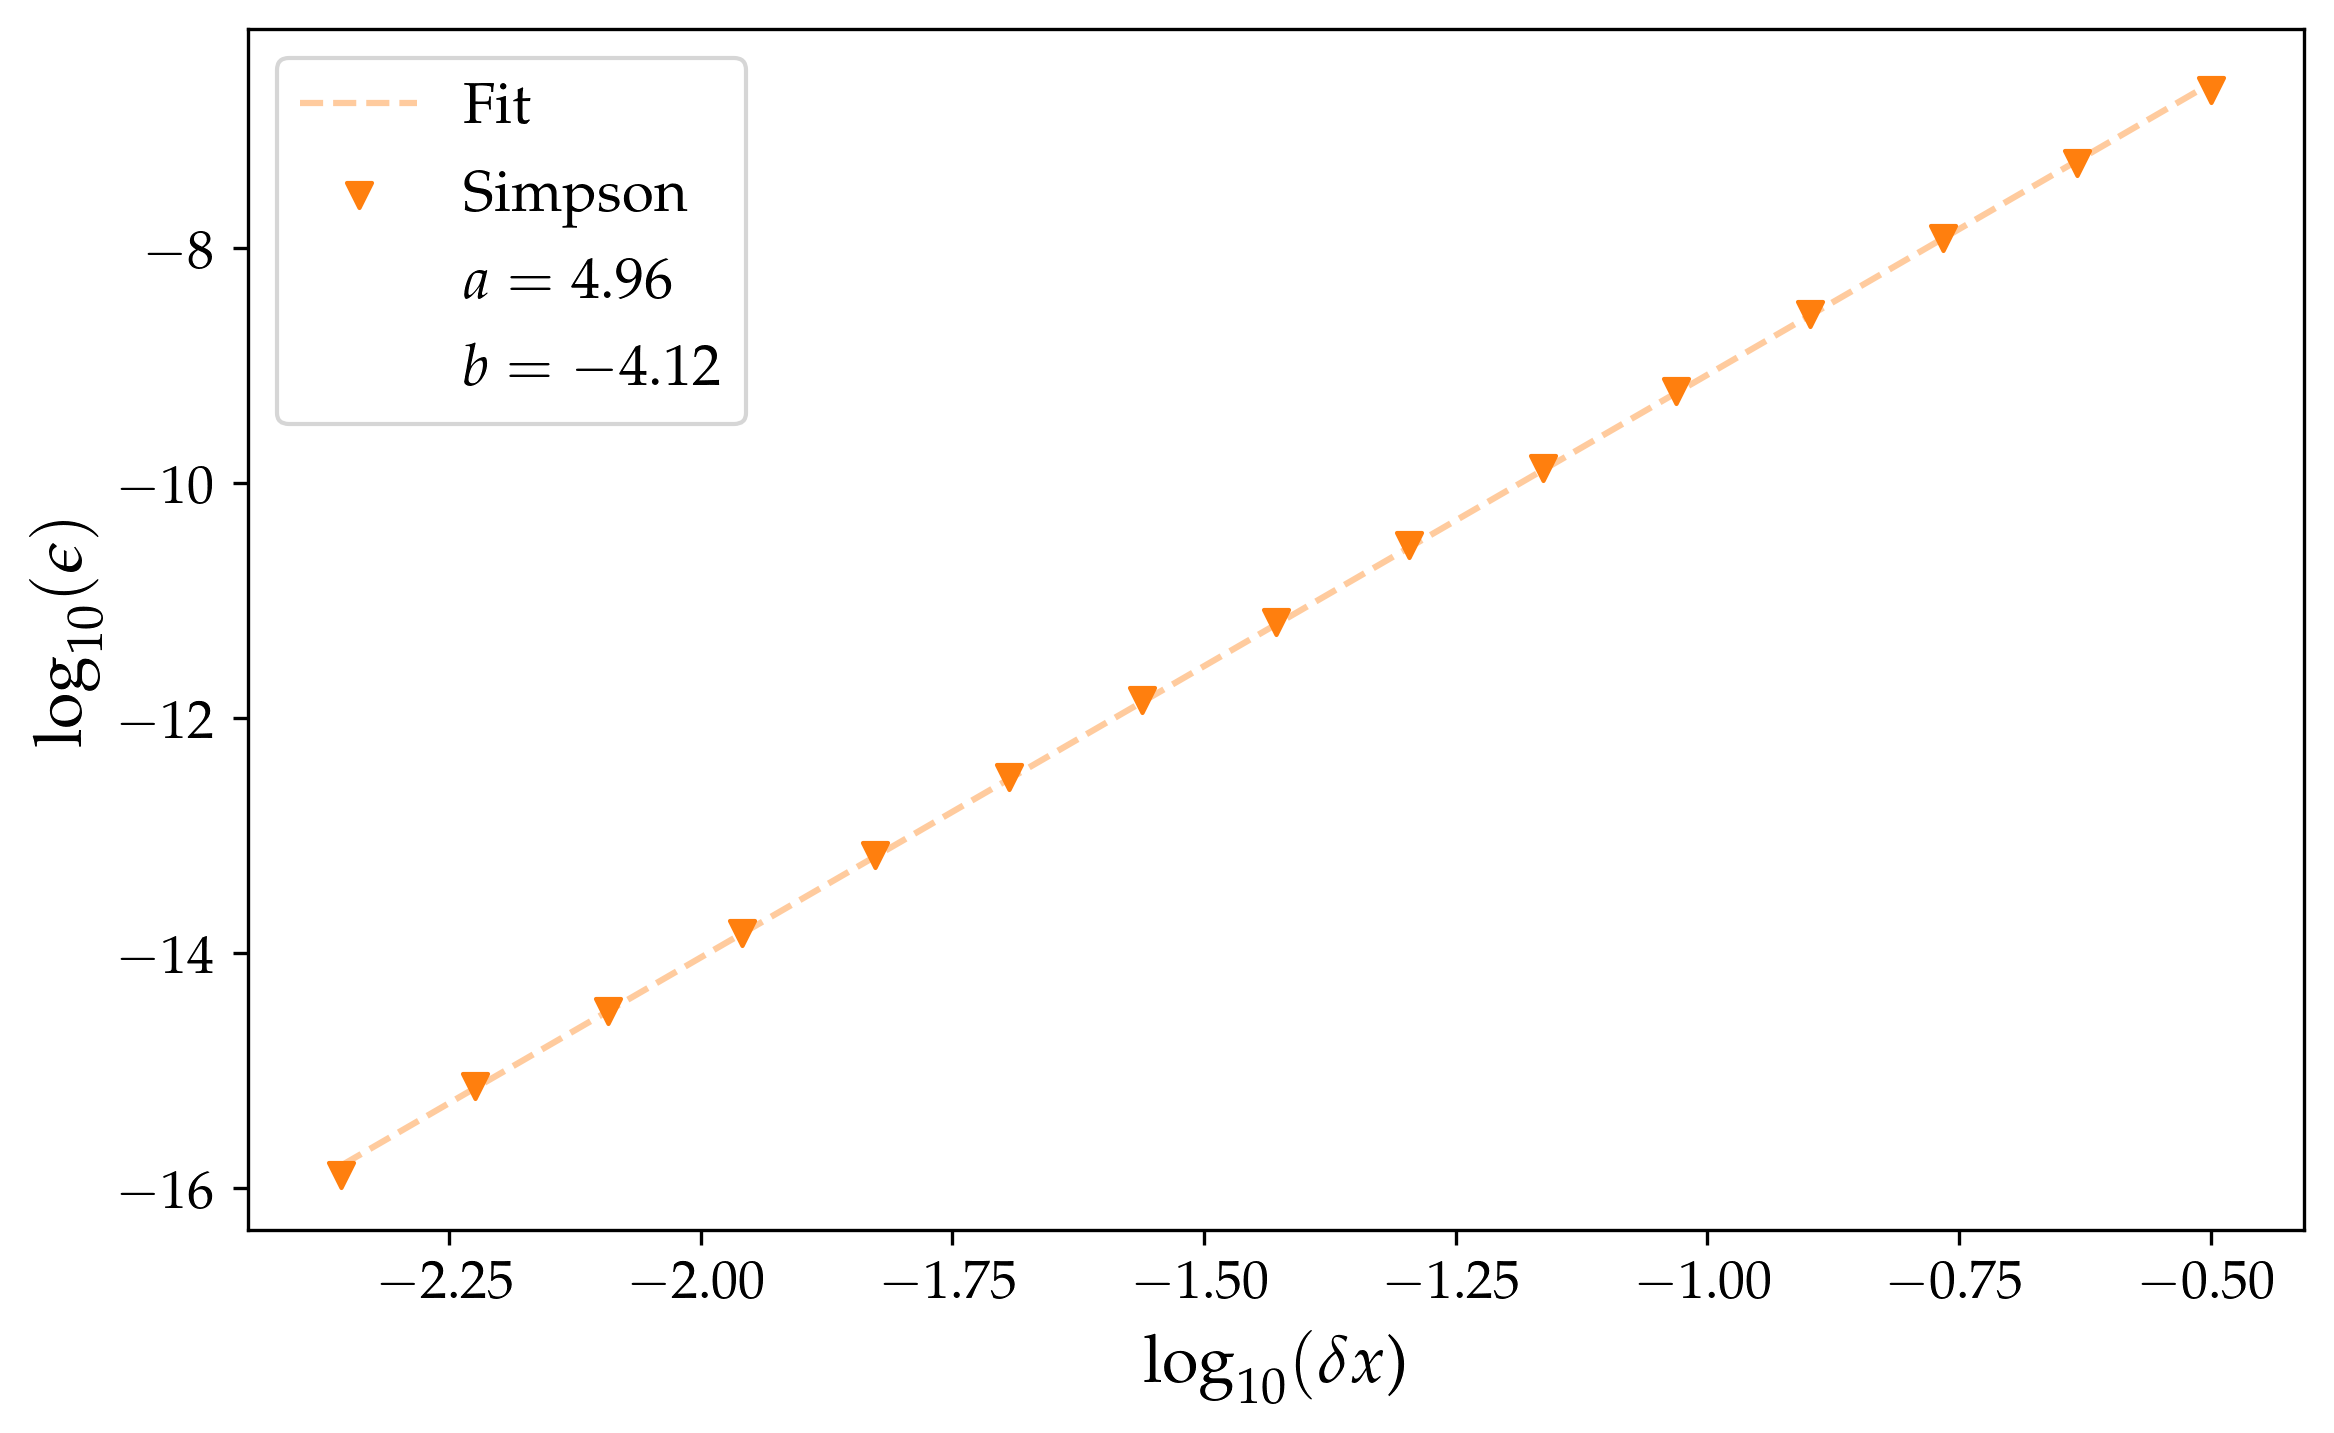

([np.float64(4.956631226616602), np.float64(-4.1236866544808235)],
 array([[0.20295858, 0.28994083],
        [0.28994083, 0.48086785]]),
 np.float64(0.013210896234469468),
 np.float64(1.0))

In [190]:
i = 1
cut = 35
dx, eps_dx = (dx_arr[cut:], error[i][cut:])

lin_fit(np.log10(dx), np.log10(eps_dx), 
        mar='v', col='C1', name_points='Simpson',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/Fit_LocSimp')

# **Let's find an approximate value for $x_{max}$**

$$
I(x_{max}) = \int_0 ^{x_{max}} \frac{x^3}{e^x - 1} dx
$$

c:\Users\Marco\Desktop\Marco\coding\Lab_comp\lib_equations.py:110: RuntimeWarning: 
Maximum iterations reached for a = 40.00, b =50.00
  warnings.warn(f'\nMaximum iterations reached for a = {a_og:.2f}, b ={b_og:.2f}', RuntimeWarning)


x0 = 48.551645373827725


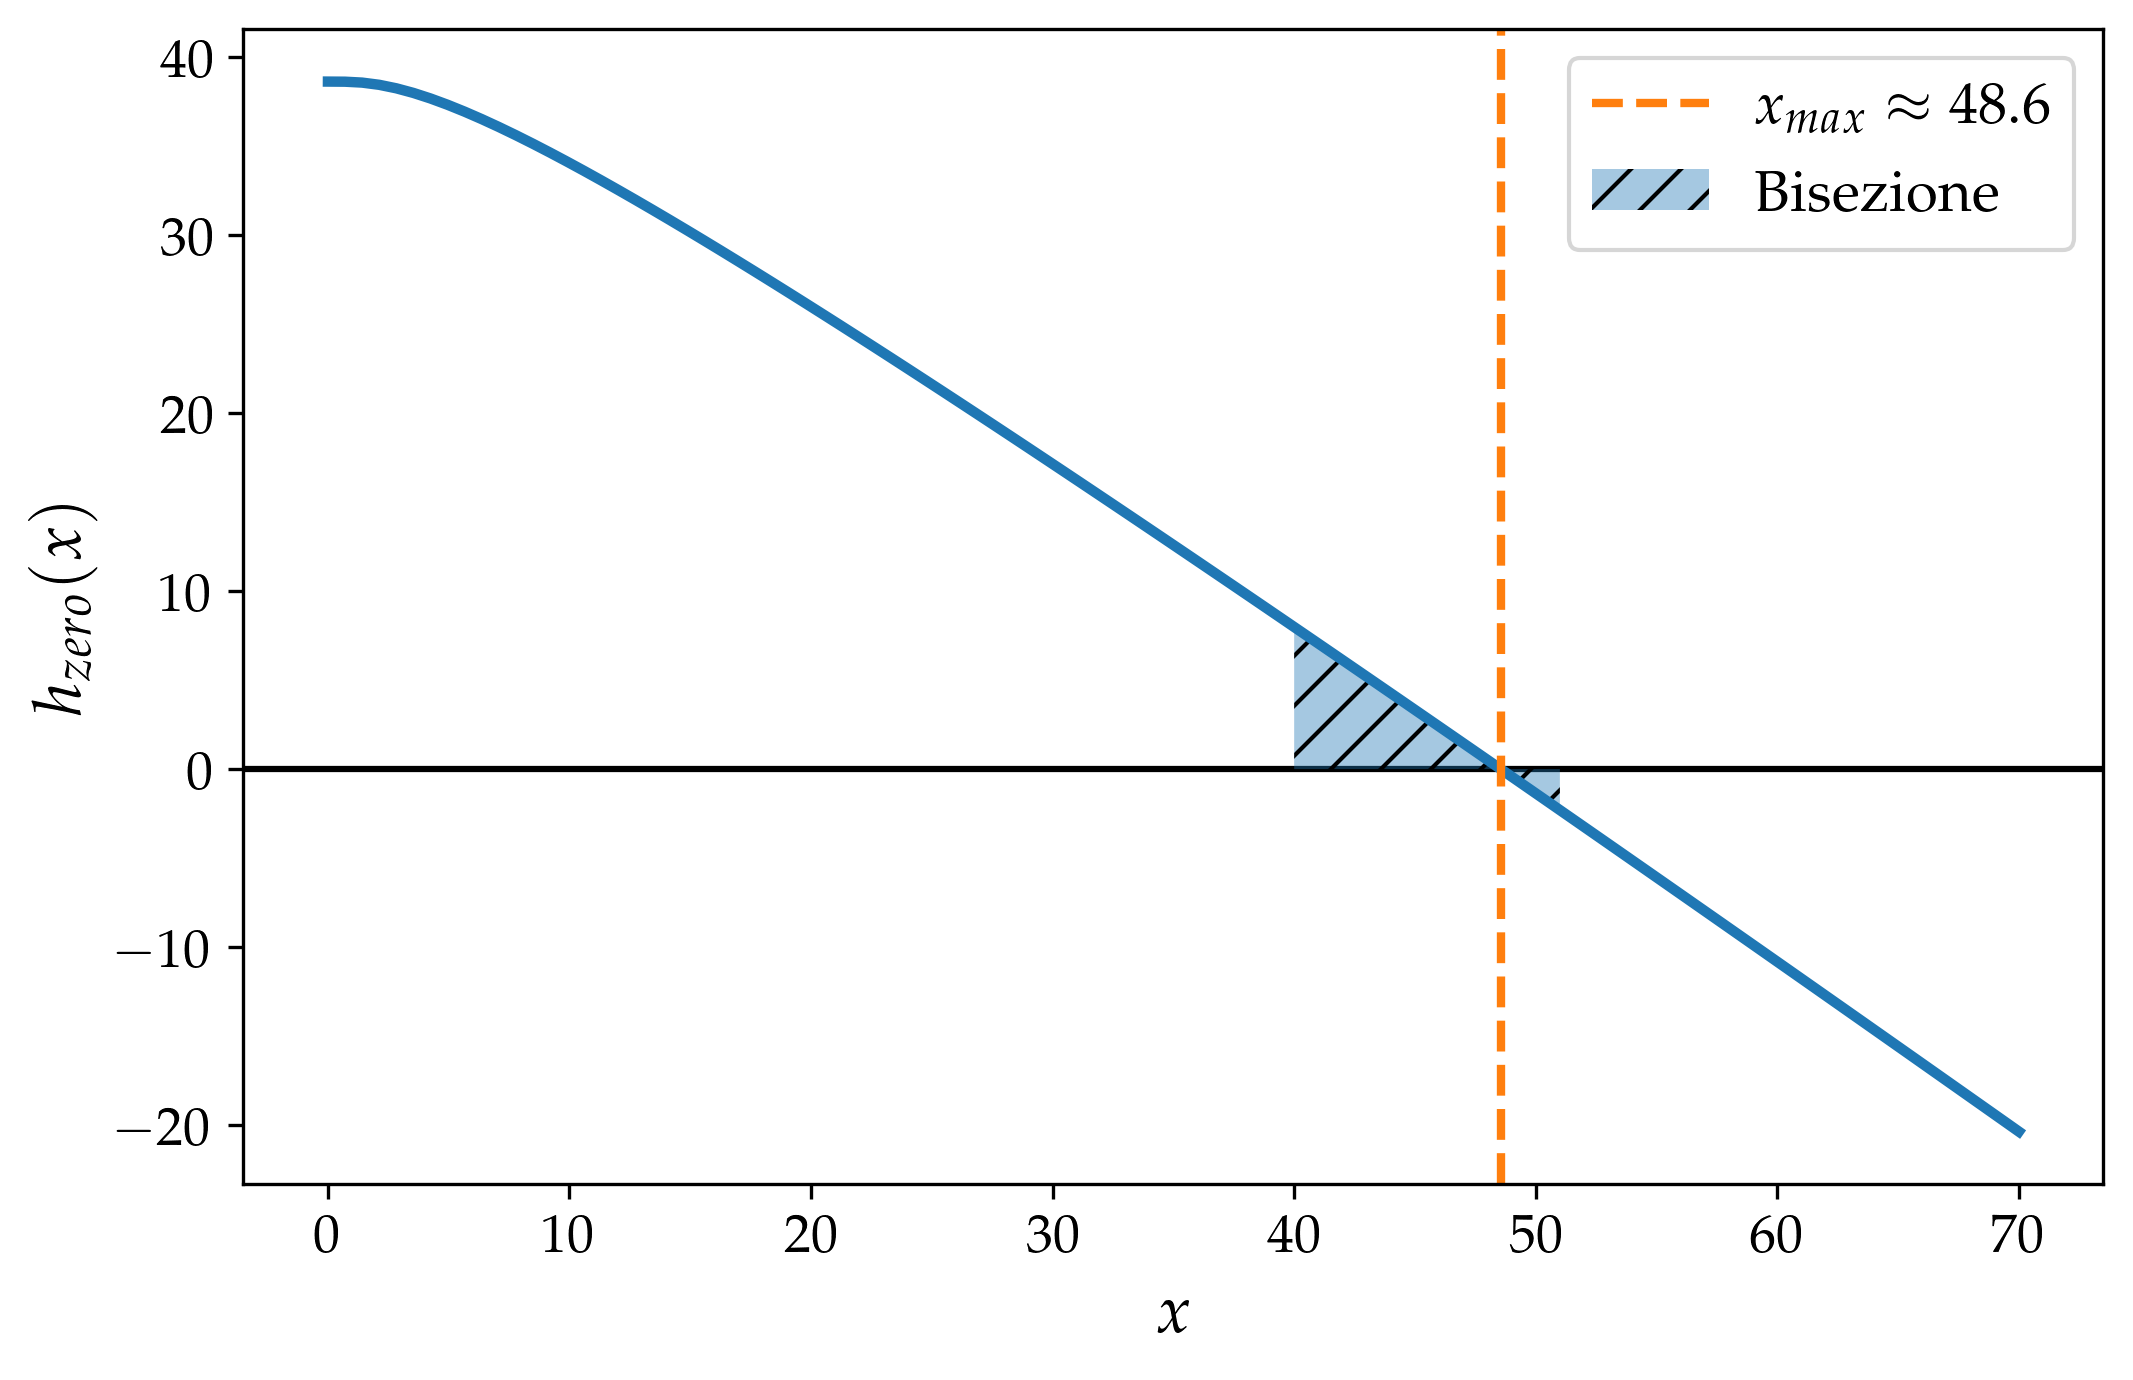

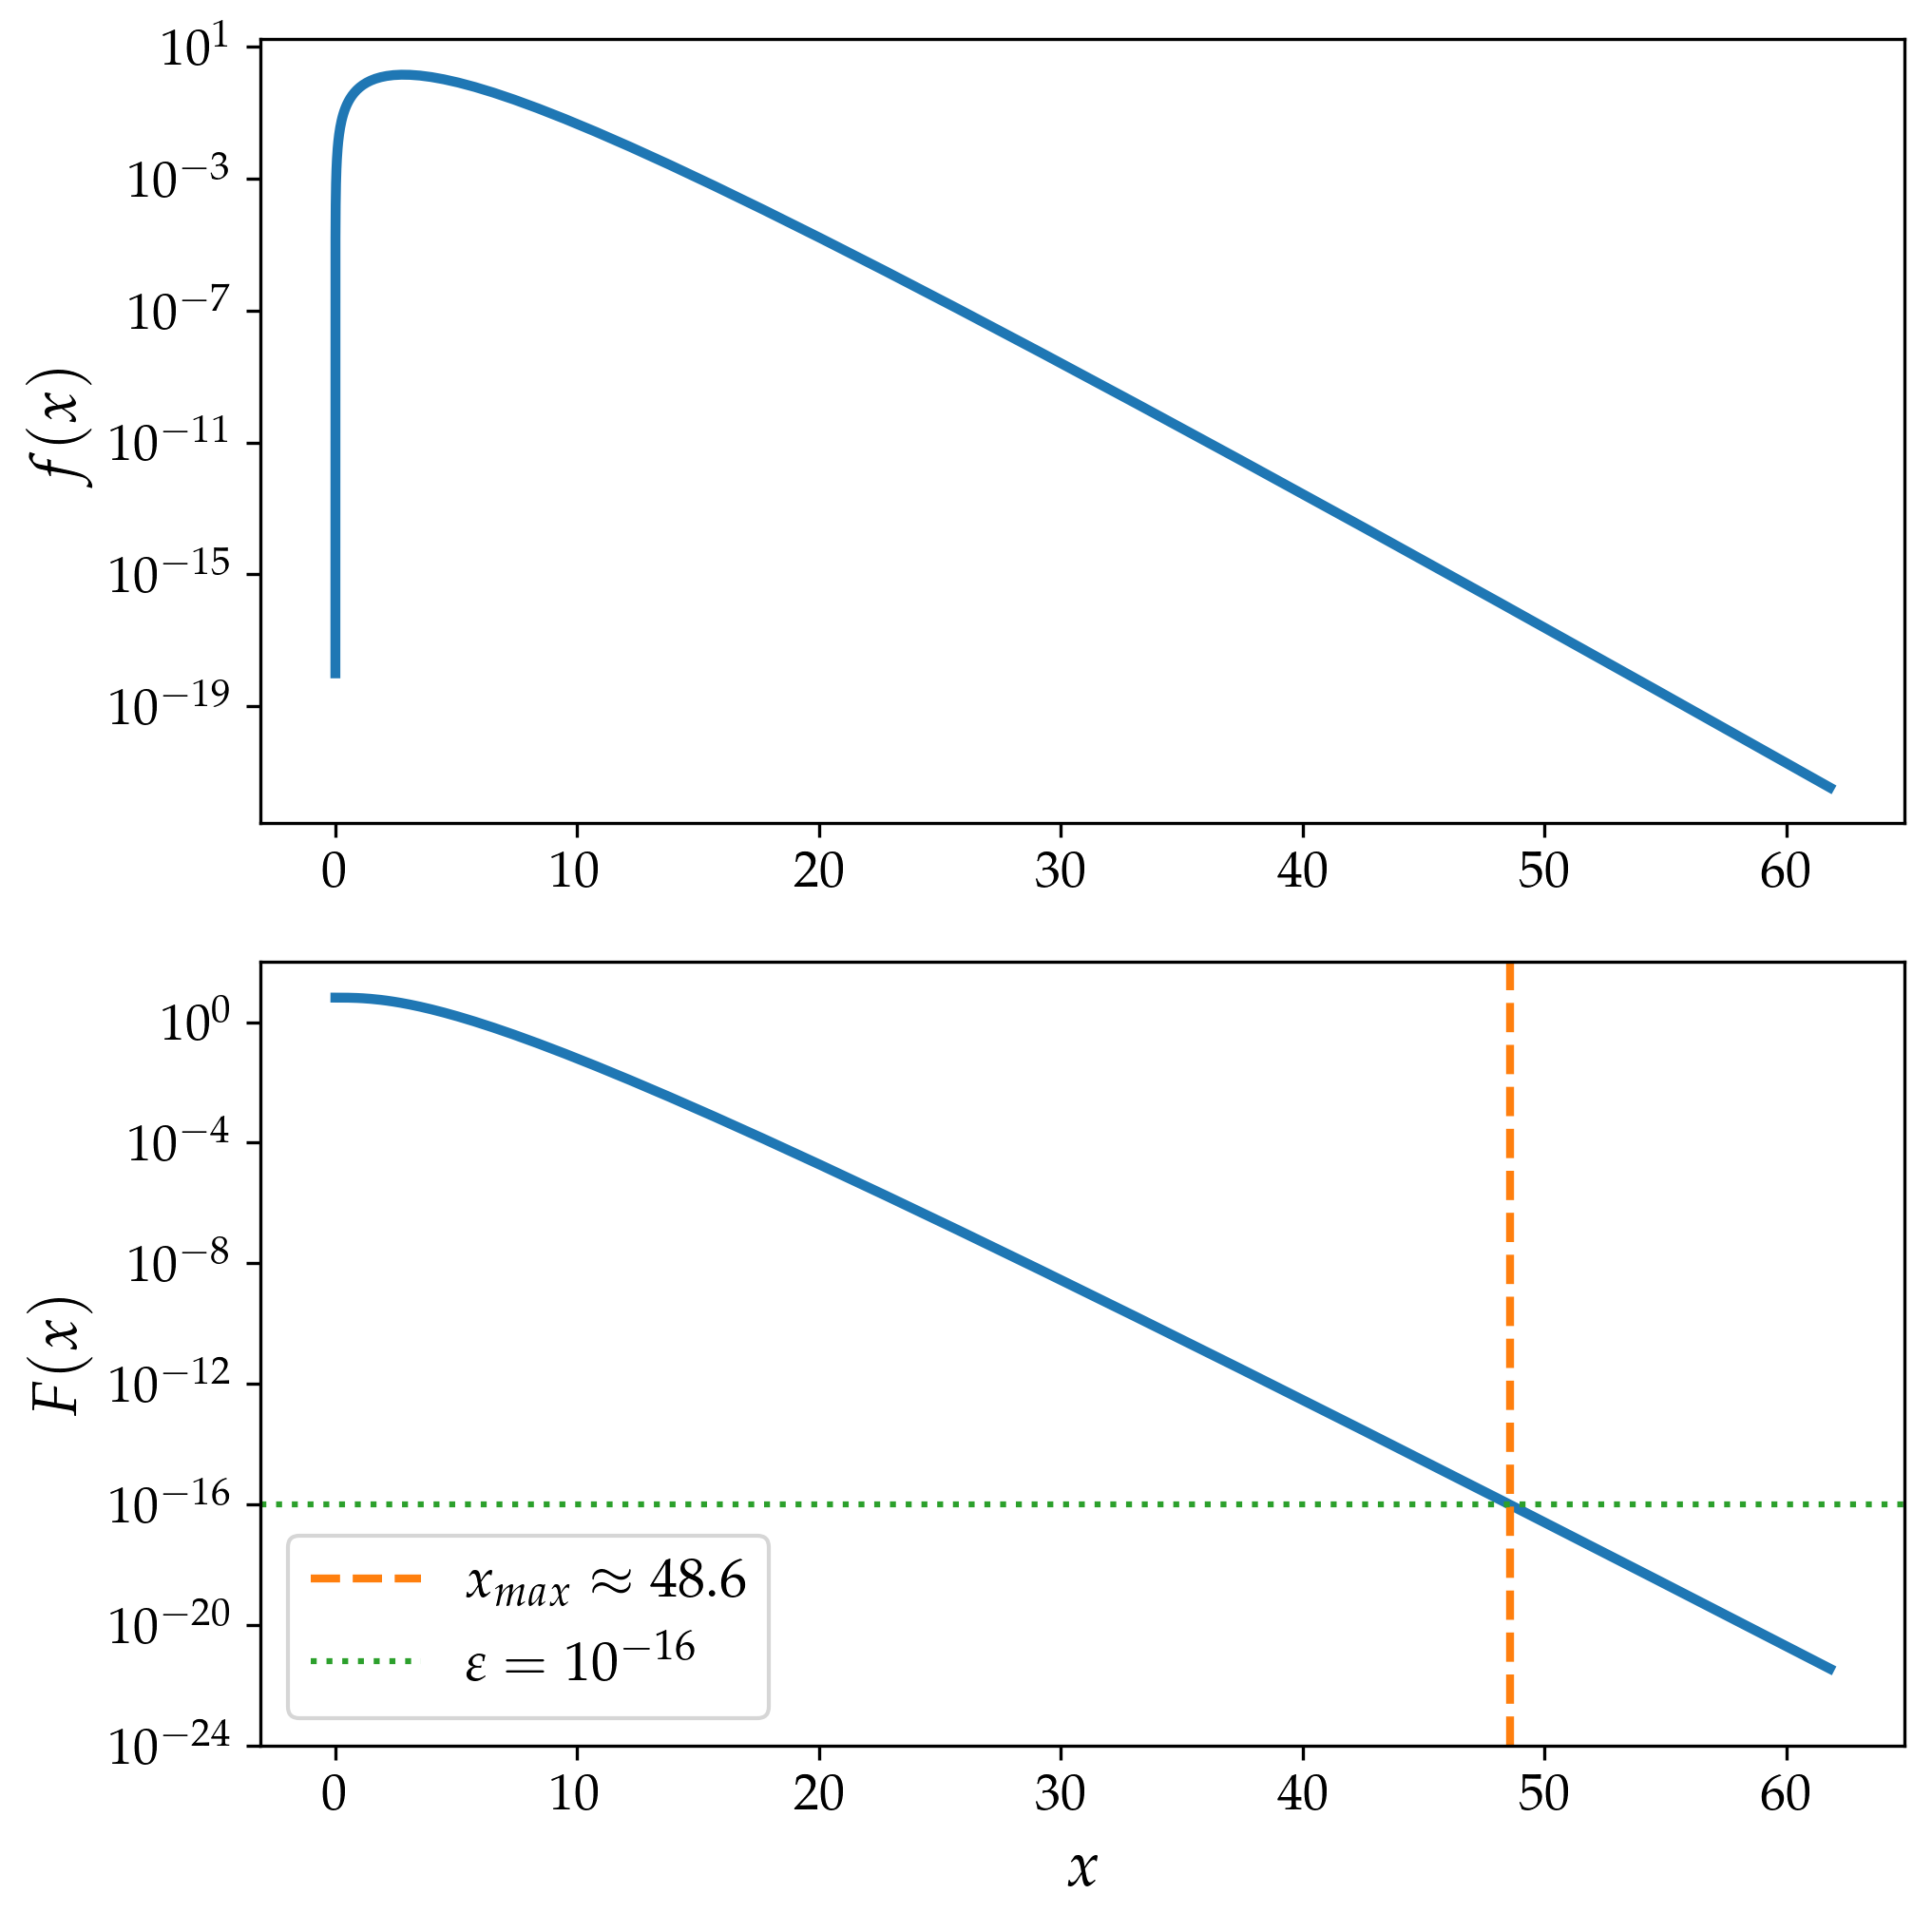

In [191]:
from lib_equations import bisec

# Params
a = 1e-9
max_samp = 70
dx_ = 1e-3
eps = 1e-16

func = lambda x: x**3 / (np.exp(x) - 1)
I_s = lambda x: Simpson(func, a, x, dx_)

zero_f = lambda x: np.log(x**3 + 3*x**2 + 6*x + 6) - (x + np.log(eps))
start, stop = (40, 50)
x_max = bisec(zero_f, start, stop, tol=eps, MaxIter=1000)
print(f'x0 = {x_max}')


zero_x = np.linspace(0, 70, 100)

plt.figure(figsize=(8, 5))
plt.plot(zero_x, zero_f(zero_x), lw=2.5)
plt.axvline(x=x_max, ls='--', color='C1', lw=2, label=rf'$x_{{max}} \approx {x_max:.1f}$')
plt.fill_between(np.linspace(start,stop+1, 100), 0, zero_f(np.linspace(start,stop+1, 100)),
                 alpha=0.4, label='Bisezione', hatch='//')

plt.xlabel(r'$x$')
plt.ylabel(r'$h_{zero}(x)$')
plt.axhline(color='black', zorder=-4)
plt.legend()

plt.savefig('plots/zero_res')
plt.show()


xcoo = np.logspace(np.log10(a), np.log10(max_samp), 200, endpoint=False)

f_x = func(xcoo)
int_s = [Simpson(func, x, max_samp, dx_) for x in xcoo]

fig, axes = plt.subplots(2,1, figsize=(7, 7))
ax0, ax1 = axes.flatten()

ax0.plot(xcoo, f_x, lw=2.5)
ax1.plot(xcoo, int_s, lw=2.5)

ax1.set_xlabel(r'$x$')
ax0.set_ylabel(r'$f(x)$')
ax1.set_ylabel(r'$F(x)$')
ax1.axvline(x_max, ls='--', color='C1', label=rf'$x_{{max}} \approx {x_max:.1f}$', lw=2)
ax1.axhline(eps, ls=':', color='C2', label=r'$\varepsilon = 10^{-16}$')
ax0.set_ylabel(r'$f(x)$')
ax0.set_yscale('log')
ax1.set_ylim(1e-24, 100)
ax1.set_yscale('log')

ax1.legend(loc='lower left')

plt.tight_layout()
plt.savefig('plots/x_int_conf')
plt.show()


In [192]:
b = x_max

res_t = trapezoidal(func, a, b, dx_)
res_s = Simpson(func, a, b, dx_)
true  = np.pi**4 / 15

# if x --> 0, f(x) --> x^2
# so the area before a can be evaluated analitically:
#   I_res = \int_(0, a) x^2 = a^3 / 3 

residual = a**3 / 3

# The numeric integral exclude the last part of the domain, 
leftover_t = trapezoidal(func, b, 2*b, dx_)
leftover_s = Simpson(func, b, 2*b, dx_)

diff_t = true - res_t  
diff_s = true - res_s 

diff_t, diff_s = abs(diff_t), abs(diff_s)

# Results
print(f'a = {a}')
print(f'b = {b}')
print('\nTrue =', true)
print(f'residual = {residual}')

print('\n\nTrapezoidal\'s Rule:')
print('\nI_t =', res_t)
print(f'leftover = {leftover_t}')
print('diff =',diff_t)

print('\n\nSimpson\'s Rule')
print('\nI_s =', res_s)
print(f'leftover = {leftover_s}')
print('diff =',diff_s)


a = 1e-09
b = 48.551645373827725

True = 6.493939402266828
residual = 3.333333333333334e-28


Trapezoidal's Rule:

I_t = 6.4939394022668235
leftover = 1.0000000734565665e-16
diff = 4.440892098500626e-15


Simpson's Rule

I_s = 6.493939402266846
leftover = 1.0000000000000095e-16
diff = 1.7763568394002505e-14


# **Comparison, knowing $x_{max}$**

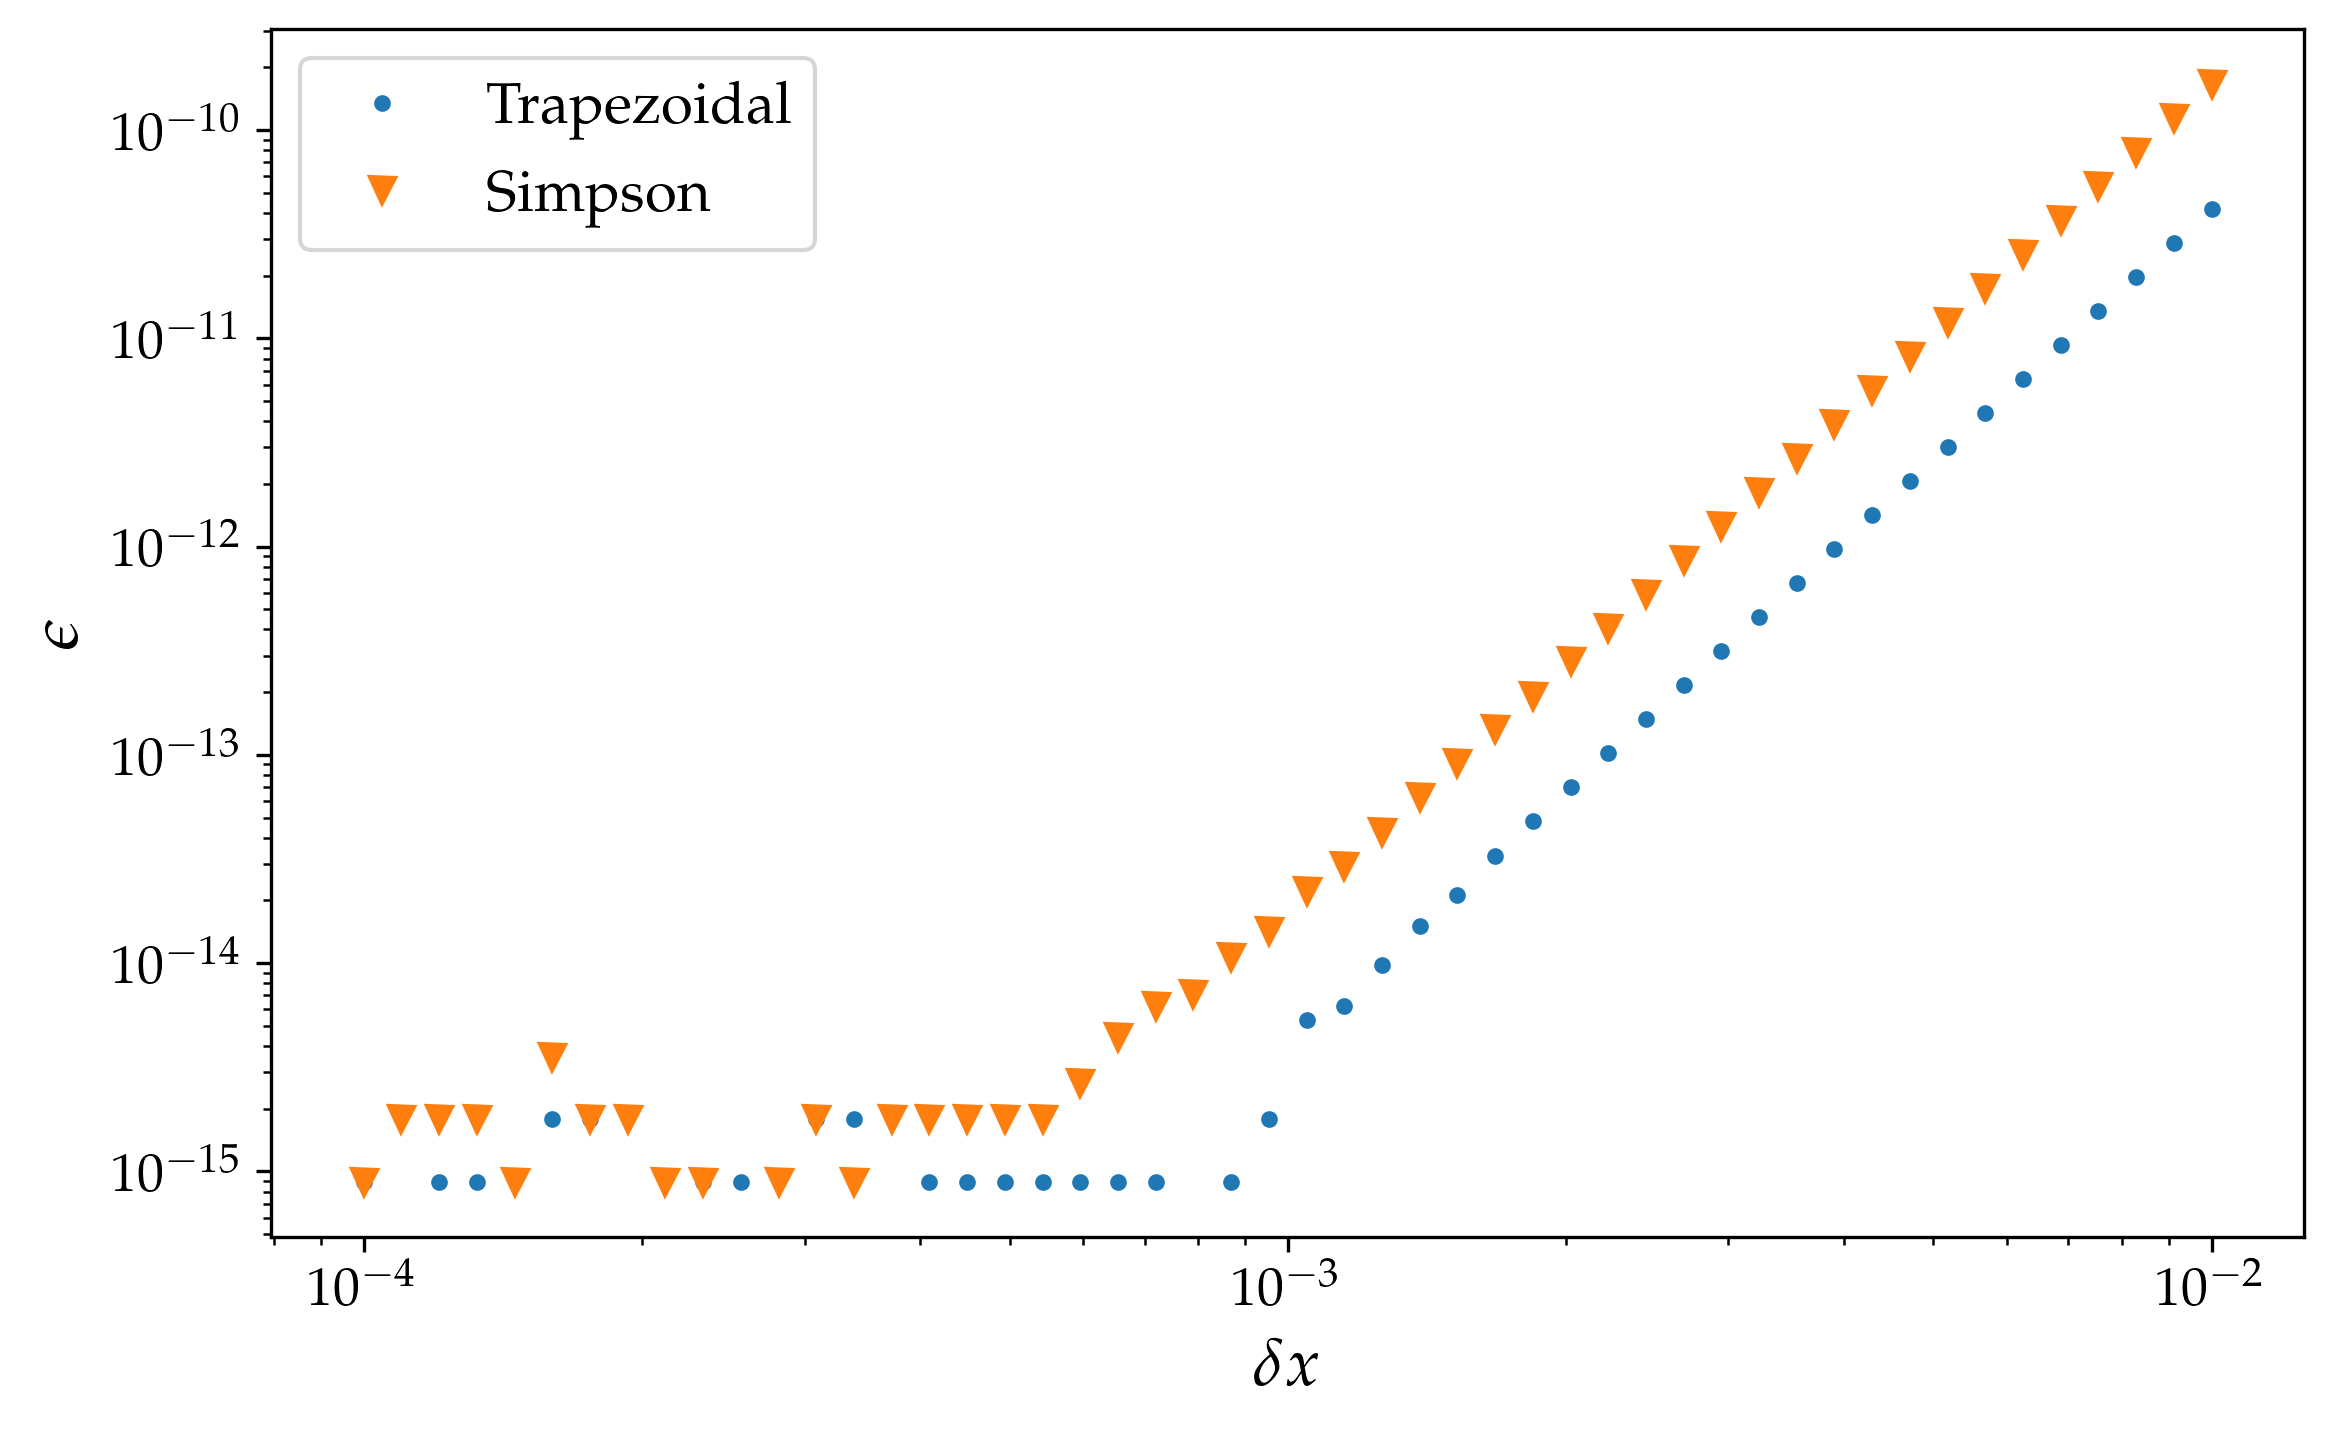

In [193]:
# Params
a = 1e-9
b = x_max
true  = np.pi**4 / 15

dx_span = np.logspace(-4, -2, 50)
true_dx = [[],[]]
eps = 1e-14
error = [[], []]

plt.figure(figsize=(8,5))
for dx_ in dx_span:
    for i in range(2):
        gr_spec = [['Trapezoidal', '.', trapezoidal], 
                [ 'Simpson', 'v', Simpson]]
        
        f_int = gr_spec[i][2]
        res = f_int(func, a, b, dx=dx_, r_true_dx=True)
        true_dx[i].append(res[1])
        err = np.abs(res[0] - true)
        error[i].append(err)

for i in range(2):
    plt.loglog(true_dx[i], error[i], ls='', marker=gr_spec[i][1], label=gr_spec[i][0])

plt.xlabel(r'$\delta x$')
plt.ylabel(r'$\epsilon$')
plt.legend()
plt.tight_layout()
plt.savefig('plots/confr_glob')
plt.show()


## **Check slope of *Trapezoidal***

dof = 13

a = 4.00e+00 +/- 1.464e+00
b = -2.38e+00 +/- 3.356e+00

Chi2 = 0.00
p-val = 1.00


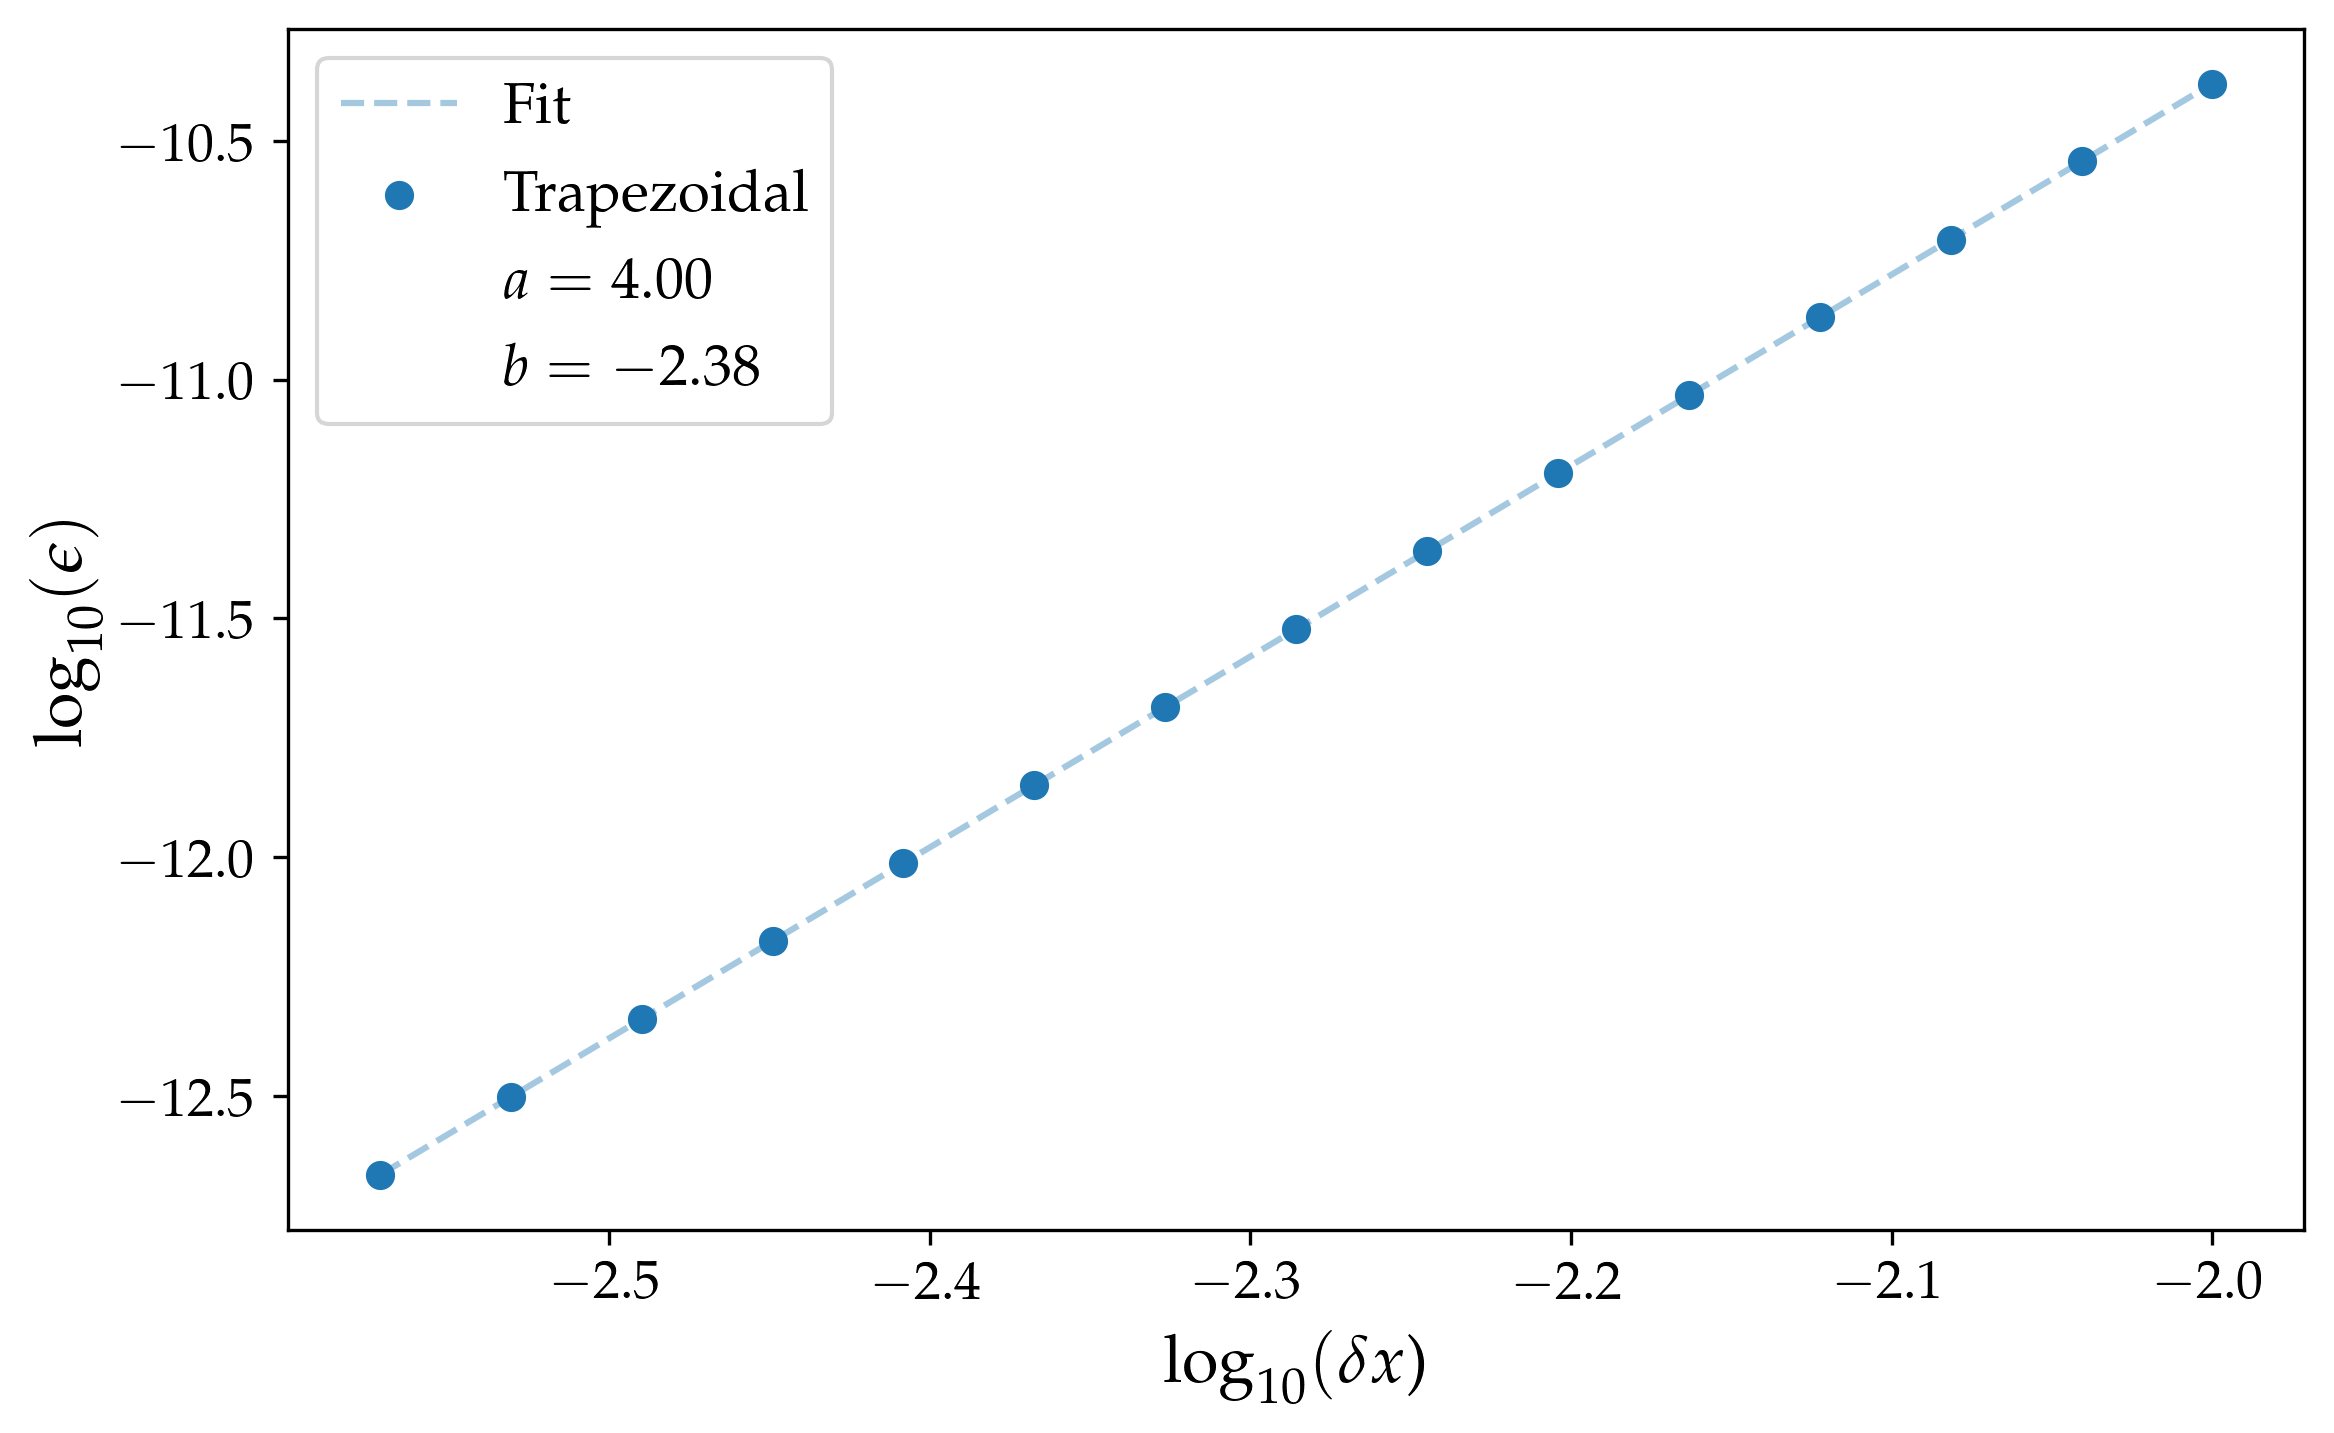

In [194]:
i = 0 
cut = 35
dx, eps_dx = (true_dx[i][cut:], error[i][cut:])

lin_fit(np.log10(dx), np.log10(eps_dx), mar='o', col='C0', name_points='Trapezoidal',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/Fit_gl_trap')

pass

## **Check slope of *Simpson***

dof = 13

a = 4.00e+00 +/- 1.464e+00
b = -1.78e+00 +/- 3.357e+00

Chi2 = 0.00
p-val = 1.00


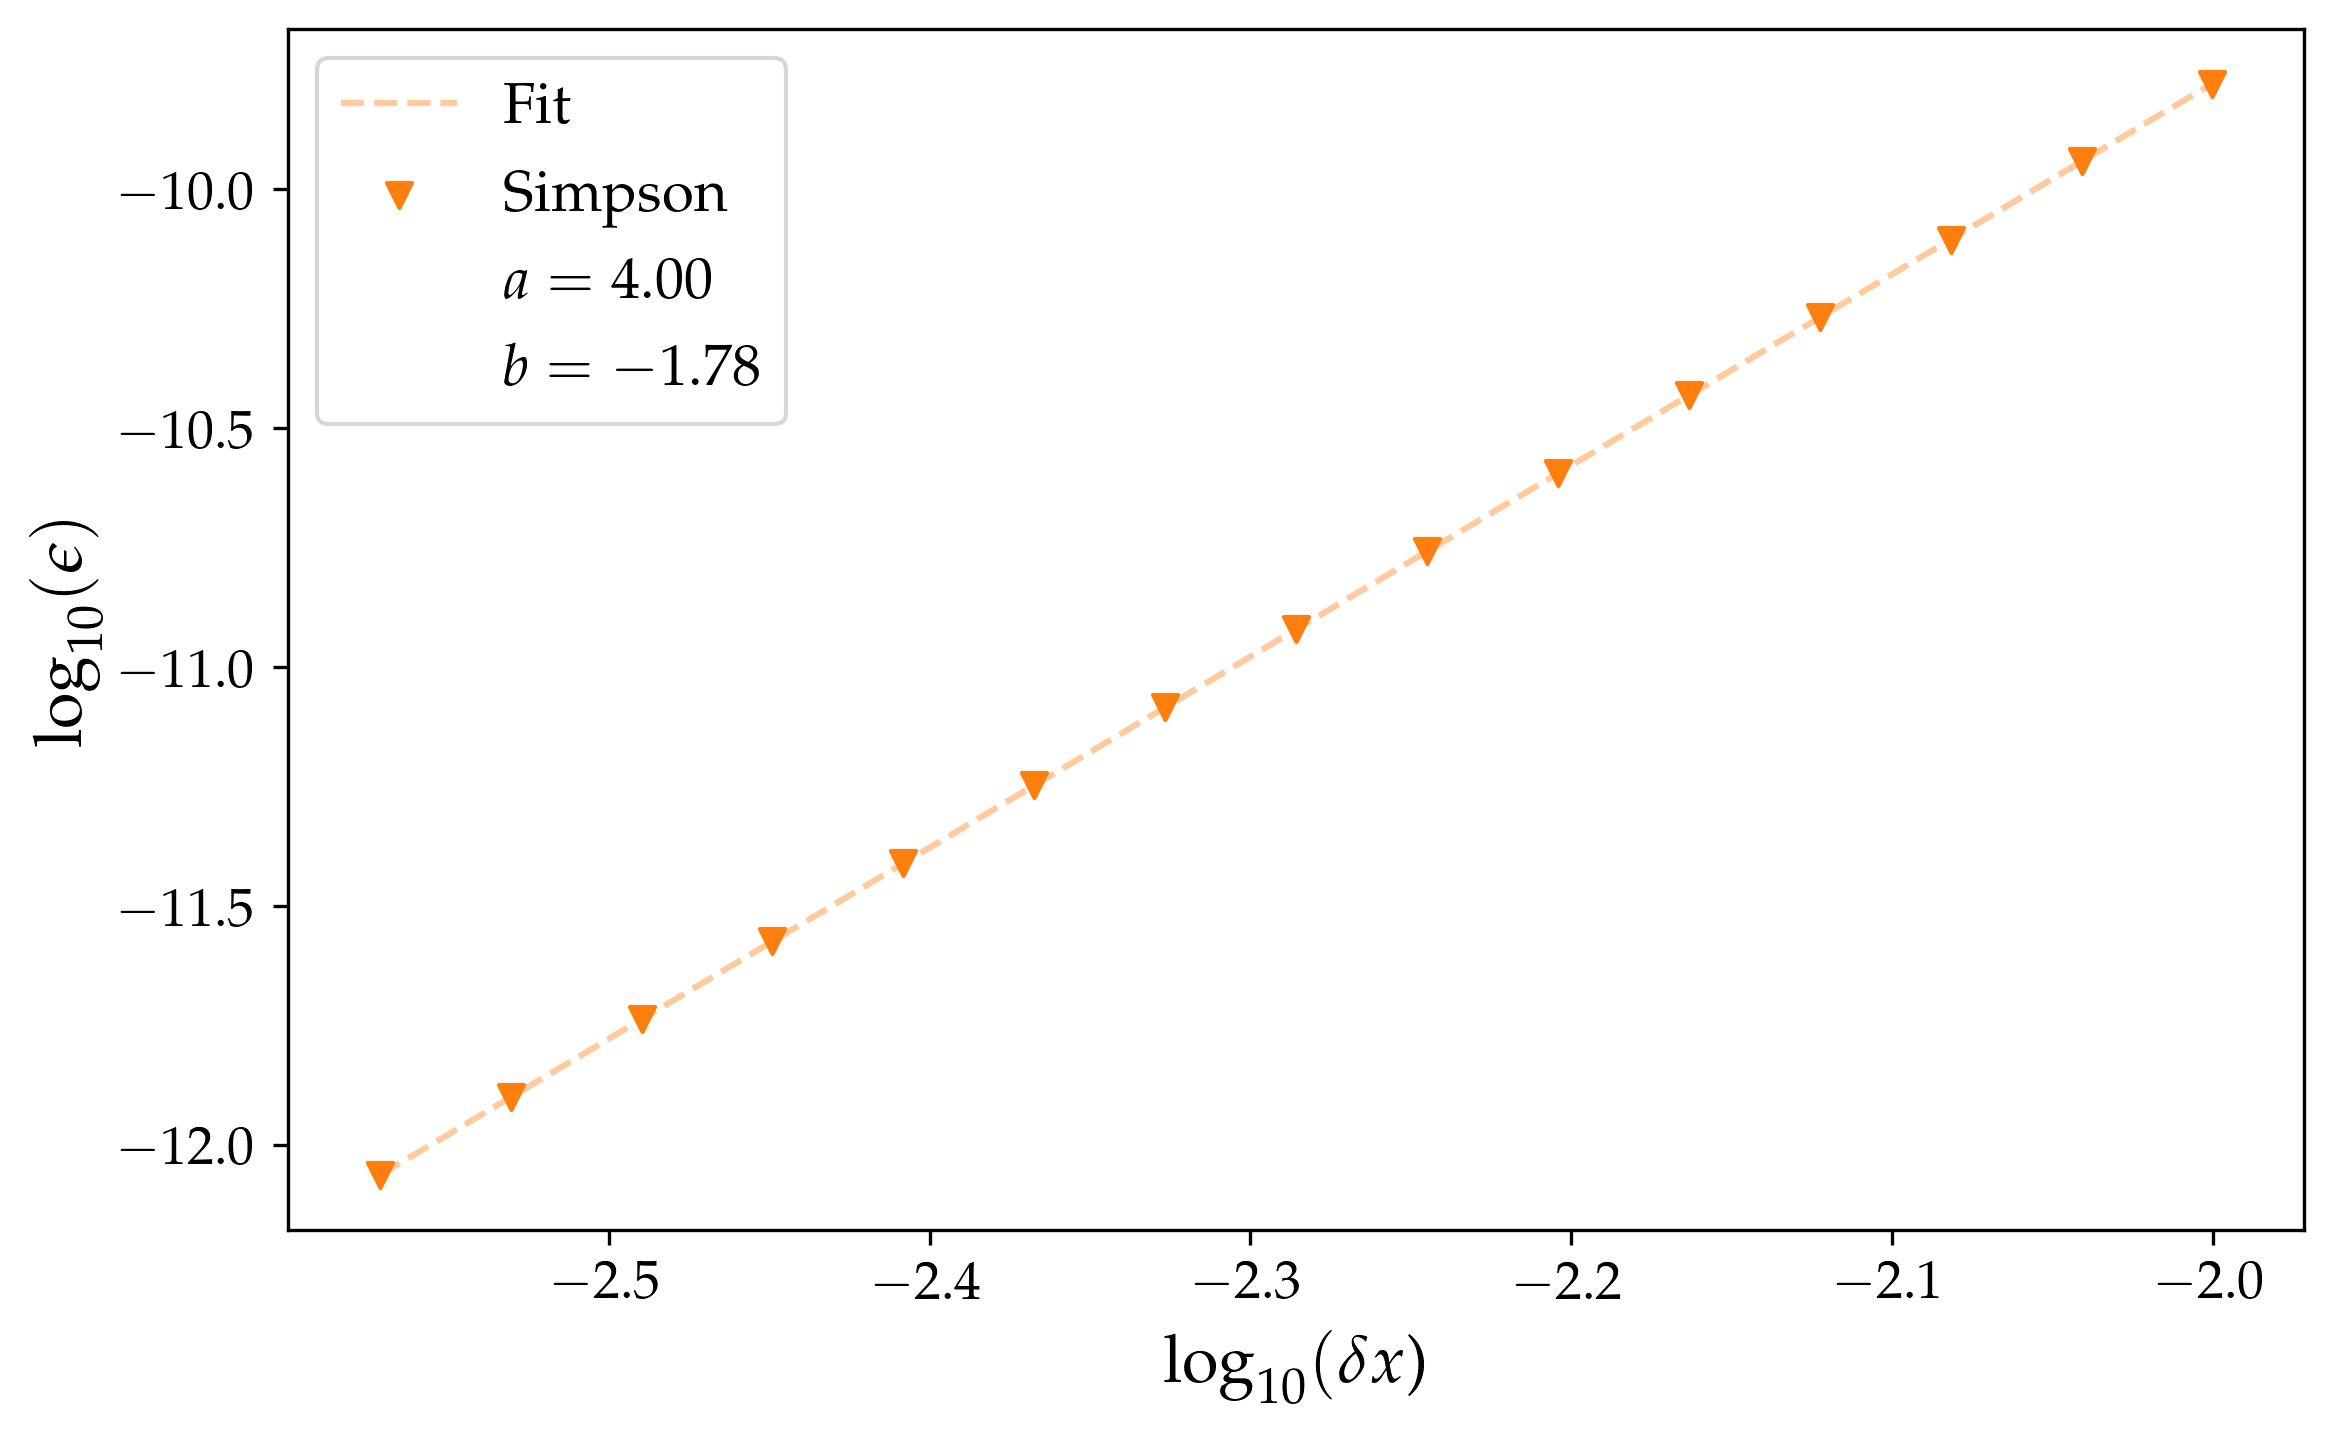

In [195]:
i = 1
dx, eps_dx = (true_dx[i][cut:], error[i][cut:])

lin_fit(np.log10(dx), np.log10(eps_dx), mar='v', col='C1', name_points='Simpson',
        labels=(r'$\log_{10}(\delta x$)', r'$\log_{10}(\epsilon)$'), save_name='plots/Fit_gl_simp')
pass

# **Study of the convergence deviation**

Df1 = -2.00e-09
Df2 = -2.00e+00


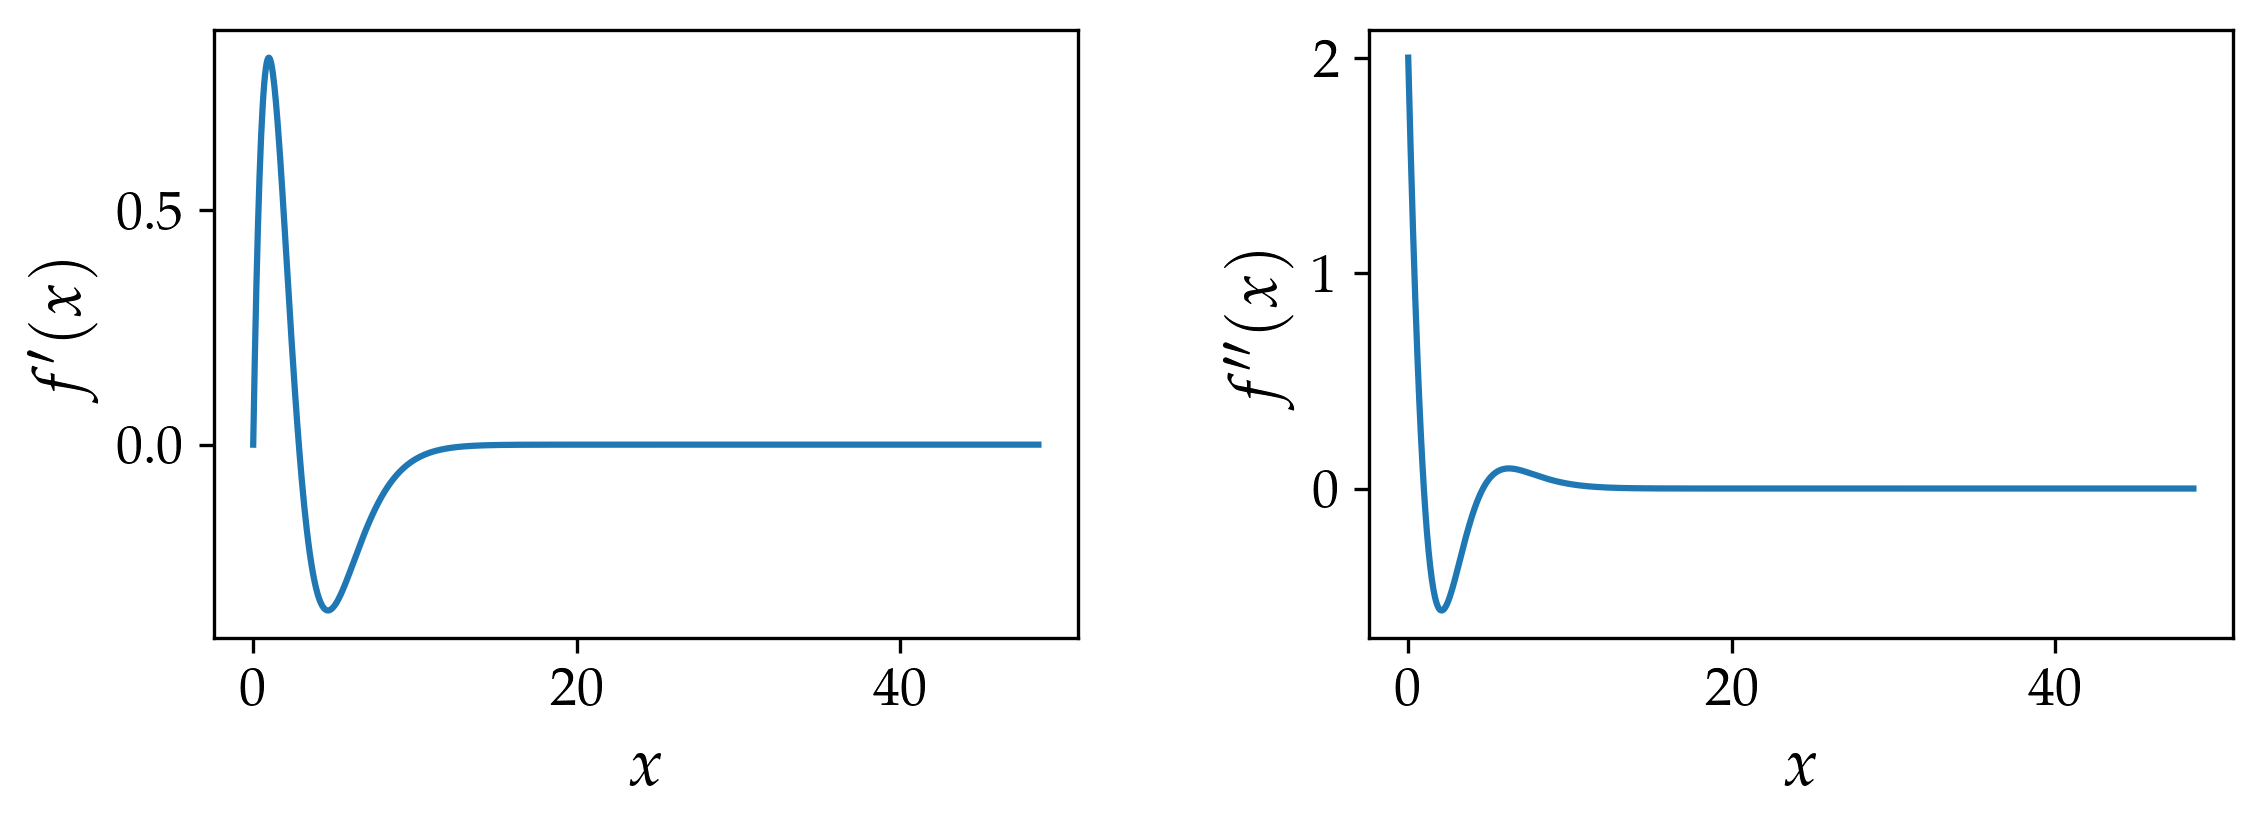

In [196]:
import sympy as sp

x_s = sp.symbols('x_s')
f_s = x_s**3 / (sp.exp(x_s) - 1) 

d1f_s = sp.diff(f_s, x_s, 1)
d2f_s = sp.diff(f_s, x_s, 2)

lamb_f = (sp.lambdify(x_s, d1f_s, "numpy"), sp.lambdify(x_s, d2f_s, "numpy"))
xcoo = np.linspace(a, b, 1000)

for n, fn in enumerate(lamb_f):
    print(f'Df{n+1} = {fn(b) - fn(a):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for n, ax in enumerate(axes):
    dn_f = lamb_f[n]
    ax.plot(xcoo, dn_f(xcoo))
    ax.set_xlabel(r'$x$')

axes[0].set_ylabel(r"$f'(x)$")
axes[1].set_ylabel(r"$f''(x)$")

plt.tight_layout()
plt.savefig('plots/der_conf')
plt.show()


